In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# Project title: Develop a Customer Intelligence System using Classification, Ensemble Learning & Clustering

# Project Workflow

## 1. Data Loading

In [5]:

df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# 2. Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [8]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

# 3. Feature Engineering

## Create a target variable:

In [13]:
df['Development_Status'] = (
    df['income'] > df['income'].median()
).astype(int)

# 4. Data Preprocessing

In [14]:
from sklearn.preprocessing import StandardScaler

X = df.drop(['country', 'Development_Status'], axis=1)
y = df['Development_Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. EDA

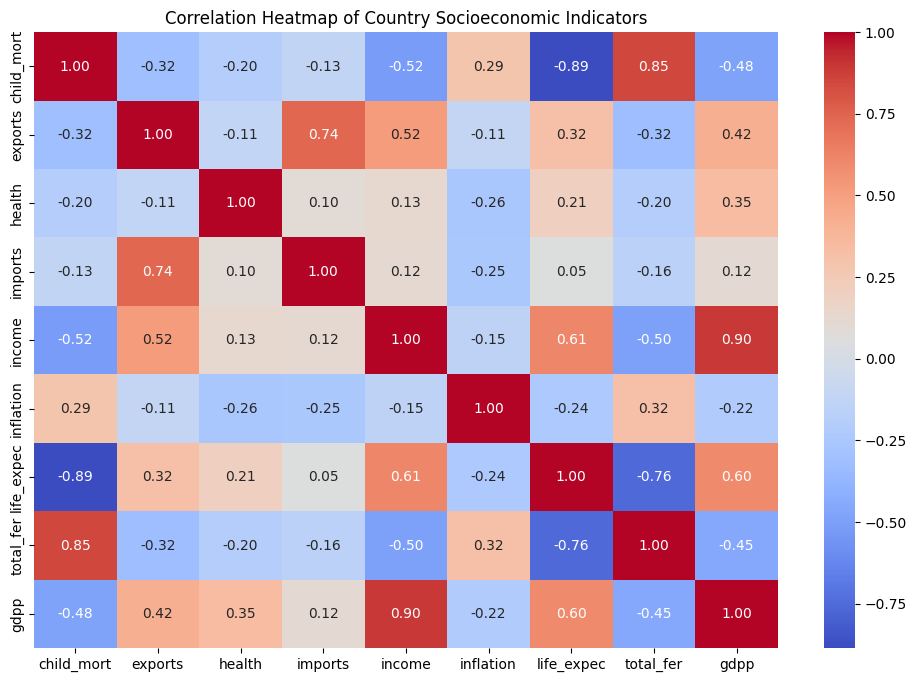

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

# Remove non-numeric column
numeric_df = df.drop('country', axis=1)

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Country Socioeconomic Indicators")
plt.show()

# 6. Classification Models
## Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_scaled, y)

LogisticRegression()

# Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_scaled, y)

RandomForestClassifier(n_estimators=200, random_state=42)

# XGBoost

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_scaled, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# 7. Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score

pred_rf = rf.predict(X_scaled)

accuracy_score(y, pred_rf)

1.0

# Evaluate:

### .Accuracy
### .Precision
### .Recall
### .F1 Score
### .ROC-AUC

# 8. K-Means Clustering

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

# 9. DBSCAN Clustering

In [25]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# 10. PCA Visualization

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

# 11. Insights

In [27]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y, lr.predict(X_scaled))
rf_acc = accuracy_score(y, rf.predict(X_scaled))
xgb_acc = accuracy_score(y, xgb.predict(X_scaled))

print("Logistic Regression:", lr_acc)
print("Random Forest:", rf_acc)
print("XGBoost:", xgb_acc)

Logistic Regression: 0.9520958083832335
Random Forest: 1.0
XGBoost: 1.0


# 12. Feature Importance (Random Forest)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

# Feature Importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
4      income    0.424602
8        gdpp    0.300345
0  child_mort    0.111111
6  life_expec    0.076628
7   total_fer    0.054434
5   inflation    0.013883
1     exports    0.009172
2      health    0.005971
3     imports    0.003854


# Country Intelligence System using Classification, Ensemble Learning & Clustering
## Project Overview

### This project develops an end-to-end Country Intelligence System using Machine Learning and Unsupervised Learning techniques to analyze socioeconomic indicators of countries. The system combines classification, ensemble learning, and clustering methods to identify development patterns, predict country categories, and generate actionable insights.

## Objectives
### .Analyze country-level socioeconomic data.
### .Predict development status using classification models.
### .Improve predictive performance using ensemble learning techniques.
### .Segment countries into meaningful groups using clustering algorithms.
### .Identify outlier countries with unique socioeconomic characteristics.

# Dataset
## Dataset: Country-data.csv

### The dataset contains socioeconomic indicators such as:

#### .Child Mortality
#### .Exports
##### .Health Expenditure
#### .Imports
#### .Income
#### .Inflation
#### .Life Expectancy
#### .Total Fertility
#### .GDP per Capita

### Technologies Used
### .Python
### .Pandas
### .NumPy
### .Matplotlib
### .Seaborn
### .Scikit-learn
### .XGBoost

# Machine Learning Workflow
## 1. Data Preprocessing
### .Data Cleaning
### .Feature Selection
### .Feature Scaling using StandardScaler
### .Target Variable Creation

## 2. Classification Models
### Used as a baseline classification model.

### .Random Forest Classifier
##### An ensemble learning algorithm that combines multiple decision trees to improve predictive performance.

### .XGBoost Classifier
##### A gradient boosting algorithm known for high accuracy and efficiency.

## 3. Clustering Models
### .K-Means Clustering
#### Used to segment countries into groups with similar socioeconomic characteristics.

### .DBSCAN
#### Density-based clustering algorithm used to identify clusters and detect outliers.

## 4. Dimensionality Reduction
### Principal Component Analysis (PCA)
#### Used for visualization and interpretation of high-dimensional data.

# Project Architecture

## Data Collection
       ↓
## Data Preprocessing
       ↓
## Feature Scaling
       ↓
## Classification Models
## (Logistic Regression,
## Random Forest,
## XGBoost)
       ↓
## Model Evaluation
       ↓
## Clustering
## (K-Means, DBSCAN)
       ↓
## PCA Visualization
       ↓
## Insights & Recommendations

# Evaluation Metrics
## Classification Metrics

### .Accuracy
### .Precision
### .Recall
### .F1-Score
### .ROC-AUC Score
### .Clustering Metrics
### .Silhouette Score
### .Cluster Distribution Analysis

### .Outlier Detection
# Key Features
## .End-to-end Machine Learning Pipeline
## .Ensemble Learning Implementation
## .Country Segmentation using Clustering
## .Outlier Detection
## .Data Visualization using PCA
## .Actionable Socioeconomic Insights

# Results
### Successfully implemented classification and clustering models.
### Segmented countries based on socioeconomic indicators.
### Identified development patterns and outlier countries.
### Compared baseline and ensemble learning performance.
### Generated data-driven insights for strategic analysis.
### Future Enhancements
### Deploy as a web application using FastAPI.
### Integrate real-time economic datasets.
### Add interactive dashboards using Power BI or Streamlit.
### Automate model retraining and monitoring.

# Author
## Rahul Kumar
